In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt



2026-01-27 19:31:14.447302: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-27 19:31:14.447864: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-27 19:31:14.546570: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-27 19:31:16.361224: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
os.chdir("..")   # Go from /notebooks to project root
print("Now cwd:", os.getcwd())

Now cwd: /home/ryu/code/DL_project


In [3]:
TRAIN_DIR = "./datasets/BT-MRI/train"
TEST_DIR = "./datasets/BT-MRI/test"

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
).flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=16,   
    class_mode="categorical"
)



Found 5712 images belonging to 4 classes.


In [6]:
test_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=16,
    class_mode="categorical"
)


Found 1311 images belonging to 4 classes.


In [7]:
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False


2026-01-27 19:31:32.598230: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(train_gen.num_classes, activation="softmax")
])


In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [10]:
history = model.fit(
    train_gen,
    epochs=4,
    validation_data=test_gen
)


Epoch 1/4
357/357 ━━━━━━━━━━━━━━━━━━━━ 135s 369ms/step - accuracy: 0.6987 - loss: 0.7575 - val_accuracy: 0.7910 - val_loss: 0.5459
Epoch 2/4
357/357 ━━━━━━━━━━━━━━━━━━━━ 148s 413ms/step - accuracy: 0.8487 - loss: 0.4295 - val_accuracy: 0.8131 - val_loss: 0.4740
Epoch 3/4
357/357 ━━━━━━━━━━━━━━━━━━━━ 146s 409ms/step - accuracy: 0.8699 - loss: 0.3626 - val_accuracy: 0.8474 - val_loss: 0.4058
Epoch 4/4
357/357 ━━━━━━━━━━━━━━━━━━━━ 130s 364ms/step - accuracy: 0.8808 - loss: 0.3264 - val_accuracy: 0.8429 - val_loss: 0.3890


In [11]:
model.save("./models/mobilenetv2_bt_mri.h5")


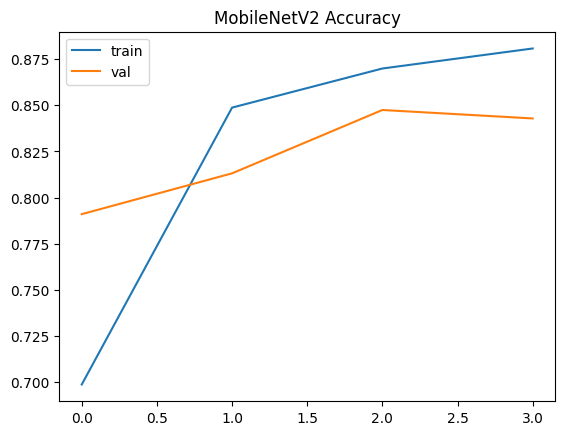

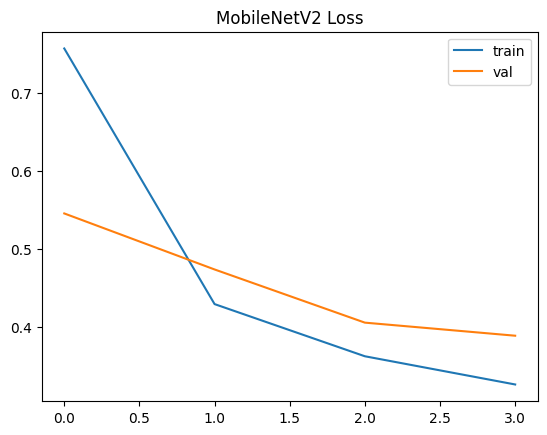

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("MobileNetV2 Accuracy")
plt.legend(["train", "val"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("MobileNetV2 Loss")
plt.legend(["train", "val"])
plt.show()
